In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import os

import cleaning as clean

In [9]:
def find_gene(df, gene):
    return df[df["HGVSc"] == gene]

---
Load Datasets

---

In [27]:
crc_data = os.path.abspath("../data/tcga_data2.csv")
lung_data = os.path.abspath("../data/lung_data.csv")
kidney_data = os.path.abspath("../data/kidney_data.csv")
brain_data = os.path.abspath("../data/brain_data.csv")
breast_data = os.path.abspath("../data/breast_data1.csv")
pancreas_data = os.path.abspath("../data/pancreatic_data.csv")
endo_data = os.path.abspath("../data/endometrial.csv")

In [29]:
crc_df = pd.read_csv(crc_data, sep = '\t', low_memory = False)
lung_df = pd.read_csv(lung_data, low_memory = False)
kidney_df = pd.read_csv(kidney_data, low_memory = False)
brain_df = pd.read_csv(brain_data, low_memory = False)
breast_df = pd.read_csv(breast_data, low_memory = False)
pancreas_df = pd.read_csv(pancreas_data, low_memory = False)
endo_df = pd.read_csv(endo_data, low_memory = False)

In [32]:
relevant = ["Gene", "Sample ID", "Cancer Type Detailed", "Mutation Type", "Variant Type", "HGVSc", "MS", 
        "Protein Change", "Functional Impact"]
age = 50

In [34]:
clean_crc = clean.clean_data(crc_df, relevant_cols = relevant, early_age = age)
clean_lungs = clean.clean_data(lung_df, relevant_cols = relevant, early_age = age)
clean_kidney = clean.clean_data(kidney_df, relevant_cols = relevant, early_age = age)
clean_brain = clean.clean_data(brain_df, relevant_cols = relevant, early_age = age)
clean_breast = clean.clean_data(breast_df, relevant_cols = relevant, early_age = age)
clean_pancreas = clean.clean_data(pancreas_df, relevant_cols = relevant, early_age = age)
clean_endo = clean.clean_data(endo_df, relevant_cols = relevant, early_age = age)

clean_brain = clean_brain[clean_brain["Age"]<=120]

C:\Users\abbi_\venv1\RSCAM\rscam-g6\Notebooks\cleaning.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.loc[:, 'Age'] = pd.to_numeric(df[age_cols].bfill(axis = 1).iloc[:, 0], errors = "coerce")


In [38]:
clean_dfs = {
    "CRC Data": clean_crc,
    "Lung Data": clean_lungs,
    "Kidney Data": clean_kidney,
    "Brain Data": clean_brain, 
    "Breast Data": clean_breast, 
    "Pancreas Data": clean_pancreas, 
    "Endometrial Data": clean_endo,
}

for name, df in clean_dfs.items():
    if (find_gene(df, "ENST00000257430.4:c.835-8A>G").shape[0] != 0):
        print(f"{name} contains the mutation.")

CRC Data contains the mutation.


---
Check that the two datasets do not contain the mutation at all

---

---

Check size of datasets

---

In [39]:
for name, df in clean_dfs.items():
    print(f"{name} has {df.shape[0]} entries.")

CRC Data has 4464 entries.
Lung Data has 290 entries.
Kidney Data has 35 entries.
Brain Data has 23 entries.
Breast Data has 169 entries.
Pancreas Data has 54 entries.
Endometrial Data has 320 entries.


---
Find mean and median age

---

In [57]:
cancers = ["colorectal", "lung", "kidney", "brain", "breast", "pancreas", "endometrial"]
i = 0
for name, df in clean_dfs.items():
    median = np.median(df["Age"].tolist())
    mean = np.mean(df["Age"].tolist())
    print(f"The median age for {cancers[i]} patients in our sample: {median:.3f}, the mean age is: {mean:.3f}")
    i+=1

mutation_crc = find_gene(clean_crc, "ENST00000257430.4:c.835-8A>G")
median = np.median(mutation_crc["Age"].tolist())
mean = np.mean(mutation_crc["Age"].tolist())
print(f"\nThe median age for colibactin CRC patients in our sample: {median:.3f}, the mean age is: {mean:.3f}")

The median age for colorectal patients in our sample: 63.000, the mean age is: 61.380
The median age for lung patients in our sample: 68.000, the mean age is: 66.159
The median age for kidney patients in our sample: 60.000, the mean age is: 60.629
The median age for brain patients in our sample: 35.000, the mean age is: 39.217
The median age for breast patients in our sample: 59.944, the mean age is: 59.898
The median age for pancreas patients in our sample: 64.500, the mean age is: 64.185
The median age for endometrial patients in our sample: 57.000, the mean age is: 58.781

The median age for colibactin CRC patients in our sample: 51.000, the mean age is: 51.286


---
Plot Distributions

---

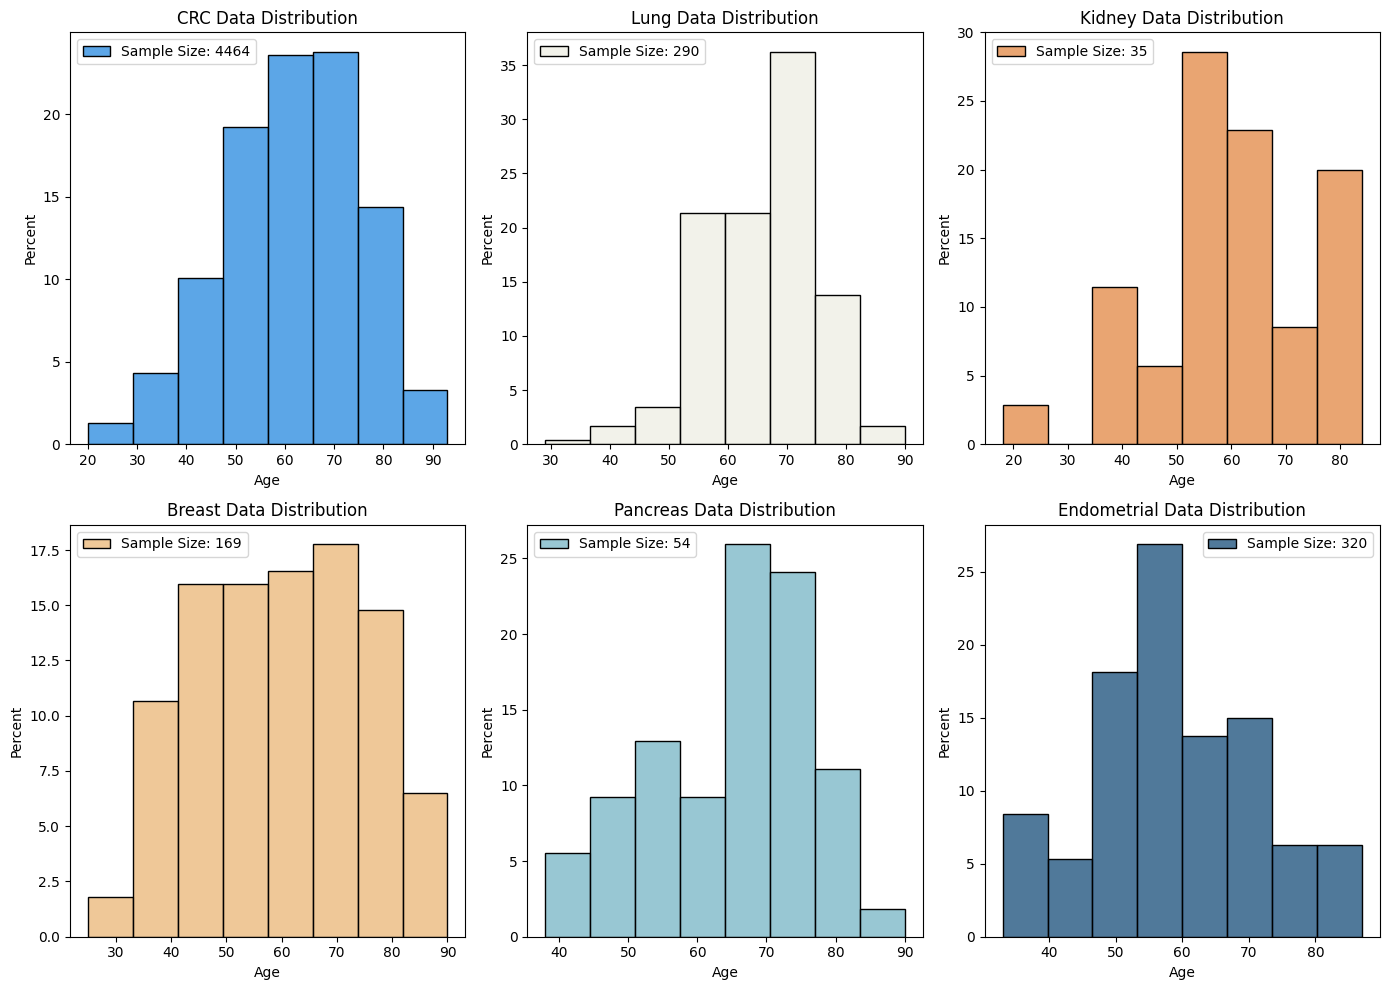

In [46]:
fig, ax = plt.subplots(2, 3, figsize = (14, 10))
colours = ["#2588DF", "#EEEEE4", "#E28743", "#EAB676", "#76b5C5", "#154C79", "#ABDBE3"]

filtered = {name: df for name, df in clean_dfs.items() if name != "Brain Data"}

ax = ax.flatten()
for i, (name, df) in enumerate(filtered.items()):
    sns.histplot(df["Age"], stat = "percent", color = colours[i], bins = 8, ax = ax[i], label = f"Sample Size: {df.shape[0]}")
    ax[i].set_title(f"{name} Distribution")
    ax[i].legend()

plt.tight_layout()
plt.show()

Pancreatic has the most similar distribution and the closest median age. This is in direct disagreement with our known cancer stats from https://seer.cancer.gov/statfacts/html/colorect.html which would suggest breast or kidney should be best. Breast is a relatively good choice too as we have a large sample size and a decent distribution, but the median age is quite a bit lower that we would like. Endometrial has a good sample size though its distribution is quite skewed. The median age is quite a bit lower. 

_We experiment with endometrial and pancreatic._

--- 
Choosing a random sample such that the mean age is similar against the entire CRC cohort.

---

In [64]:
sample_size = 200
target_mean = np.mean(clean_crc["Age"].tolist())
eps = 10e-1

while True:
    sample1 = clean_endo.sample(sample_size)
    if abs(np.mean(sample1["Age"].tolist()) - target_mean) < eps:
        break

print(f"The sample mean for endometrial cancer is {np.mean(sample1["Age"].tolist())}")
print(f"The mean of the entire colorectal cancer cohort is {target_mean}")

# while True:
#     sample2 = clean_pancreas.sample(sample_size)
#     if abs(np.mean(sample2["Age"].tolist()) - target_mean) < eps:
#         break

# print(f"The sample mean for pancreatic cancer is {np.mean(sample2["Age"].tolist())}")

The sample mean for endometrial cancer is 60.785
The mean of the entire colorectal cancer cohort is 61.380376344086024


---
Attempting Mann Whitney Test on samples

---

In [65]:
import mann_whitney as mw

mw.run_simulation(mutation_crc, sample1, alpha =0.05, n_iterations = 100, sample_size = 35)

Rejections: 97 in 100 tests
